In [1]:
import sys
sys.path.insert(0, '..')

In [2]:
import utils
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import bootstrap as scipy_bootstrap

## Cargar datos

In [3]:
clusters = pd.read_csv('./../data/processed/largest_clusters.csv')
members = pd.read_csv('./../data/processed/largest_clusters_members.csv')

Seleccionar miembros con velocidad radial.

In [4]:
mask_rv = members['RV'].notna()
members_rv = members[mask_rv].copy()

Seleccionar datos del cúmulo

In [25]:
cluster_name = 'NGC_3201'
cluster = clusters[clusters['Name'] == cluster_name]
cluster_members = members[members['Name'] == cluster_name]
cluster_members_rv = members_rv[members_rv['Name'] == cluster_name]

In [26]:
print(f"Miembros totales      : {len(cluster_members)}")
print(f"Con velocidad radial  : {len(cluster_members_rv)}  ({100*len(cluster_members_rv)/len(cluster_members):.1f}%)")

Miembros totales      : 25371
Con velocidad radial  : 241  (0.9%)


## Proyección gnomónica

In [27]:
ra0 = float(cluster['RA_ICRS'].values[0])  # grados
dec0 = float(cluster['DE_ICRS'].values[0]) # grados
d0 = float(cluster['dist50'].values[0])    # pc

In [28]:
ras = cluster_members_rv['RA_ICRS'].values  # grados
decs = cluster_members_rv['DE_ICRS'].values # grados

In [29]:
X, Y = utils.tangent_plane_projection(ras, decs, ra0, dec0, d0)

## Definir bins

Calcular radios superficiales.

In [30]:
Rs = np.sqrt(X**2 + Y**2)
cluster_members_rv['R'] = Rs

Definir número de bines

In [31]:
N_rv = len(cluster_members_rv)
n_bins = max(3, int(np.sqrt(N_rv))) # regla de N**0.5 y mínimo 3 bins
min_stars = 3                       # umbral de calidad

Percentiles que definen los bordes de cada bin.

In [32]:
percentiles = np.linspace(0, 100, n_bins + 1)
edges = np.percentile(cluster_members_rv["R"], percentiles)
edges[0] -= 1e-6 # incluir el radio mínimo exacto
edges[-1] += 1e-6

In [33]:
print(f"\nNúmero de bins        : {n_bins}")
print(f"Bordes de bins (pc)   : {np.round(edges, 3)}")


Número de bins        : 15
Bordes de bins (pc)   : [  0.163   2.185   3.064   3.554   4.366   5.096   6.083   7.201   8.597
  11.889  13.444  17.969  22.572  32.454  48.468 141.799]


## Calcular $\sigma_{\text{obs}}(r)$ en cada bin

In [ ]:
results = []

for i in range(n_bins):
    R_lo, R_hi = edges[i], edges[i + 1]
    R_mid = 0.5 * (R_lo + R_hi)

    # Estrellas del bin con RV válida
    in_bin = cluster_members_rv[(cluster_members_rv["R"] >= R_lo) & (cluster_members_rv["R"] < R_hi)]
    n = len(in_bin)
    vr = in_bin["RV"].values

    if n < min_stars:
        # Bin descartado: insuficientes datos
        results.append({
            "R_mid": R_mid, "R_lo": R_lo, "R_hi": R_hi,
            "sigma": np.nan, "sigma_err": np.nan, "n": n
        })
        continue

    # Varianza 
    v_mean = np.mean(vr)
    sigma2 = np.sum((vr - v_mean) ** 2) / (n - 1)
    sigma  = np.sqrt(sigma2)

    # Error en sigma con bootstrap (percentil 16–84 ≈ ±1σ)
    def sigma_statistic(v, axis=-1):
        return np.std(v, ddof=1, axis=axis)

    boot = scipy_bootstrap(
        (vr,),
        sigma_statistic,
        n_resamples=2000,
        confidence_level=0.68,   # ±1 sigma equivalente
        method="percentile",
        random_state=42
    )
    sigma_lo = sigma - boot.confidence_interval.low
    sigma_hi = boot.confidence_interval.high - sigma
    sigma_err = 0.5 * (sigma_lo + sigma_hi)  # error simétrico aproximado

    results.append({
        "R_mid": R_mid, "R_lo": R_lo, "R_hi": R_hi,
        "sigma": sigma, "sigma_err": sigma_err, "n": n
    })

Definir dataframe con los resultados por bin.

In [35]:
df_res = pd.DataFrame(results)
valid  = df_res["sigma"].notna()

Resultados por bin:

In [46]:
df_res

,R_mid,R_lo,R_hi,sigma,sigma_err,n
0,1.173956,0.162930,2.184982,4.260415,0.537259,16
1,2.624463,2.184982,3.063943,5.651371,1.104119,16
2,3.308854,3.063943,3.553764,23.531953,8.233434,16
3,3.959796,3.553764,4.365827,4.738418,0.915157,16
4,4.731131,4.365827,5.096435,14.529005,7.217312,17
5,5.589680,5.096435,6.082925,6.795478,1.304700,15
6,6.641919,6.082925,7.200912,5.851795,2.070885,17
7,7.898862,7.200912,8.596812,3.614441,0.643590,15
8,10.242875,8.596812,11.888938,7.480329,2.208466,16
9,12.666363,11.888938,13.443788,5.402231,0.742645,17


## Gráfica

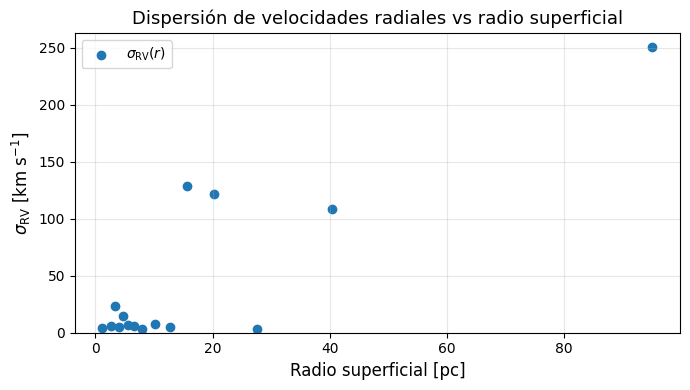

In [45]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.scatter(df_res['R_mid'], df_res['sigma'], label=r"$\sigma_\mathrm{RV}(r)$")
ax.set_xlabel("Radio superficial [pc]", fontsize=12)
ax.set_ylabel(r"$\sigma_\mathrm{RV}$ [km s$^{-1}$]", fontsize=12)
ax.set_title("Dispersión de velocidades radiales vs radio superficial", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()